# Correlación ONI ↔ Precipitación por municipio
**Objetivo:** identificar los municipios con mayor correlación entre el índice ONI y la precipitación mensual, usando Pearson y Spearman con rezagos 0–3.

Resultados: top 10 municipios con mayor correlación negativa (El Niño reduce lluvia) para cada método.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ── Configuración ─────────────────────────────────────────────────────────
CHIRPS_DIR  = r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon\ETL_code\data\processed\chirps_municipal"
ONI_DIR     = r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon\ETL_code\data\processed\noaa_historical"

ANIO_INICIO = 1990
ANIO_FIN    = 2025
MAX_LAG     = 6    # rezagos a evaluar (0, 1, 2, 3)
MIN_OBS     = 24   # mínimo de observaciones para calcular correlación
TOP_N       = 10   # municipios a mostrar en el ranking

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
def cargar_oni(data_dir: str, anio_inicio: int, anio_fin: int) -> pd.DataFrame:
    """Lee los parquet anuales de ONI para el rango indicado."""
    archivos = [
        os.path.join(data_dir, f"year={a}", f"noaa_oni_{a}.parquet")
        for a in range(anio_inicio, anio_fin + 1)
        if os.path.exists(os.path.join(data_dir, f"year={a}", f"noaa_oni_{a}.parquet"))
    ]
    if not archivos:
        raise FileNotFoundError(f"No se encontraron parquet ONI en {data_dir}")

    df = pd.concat([pd.read_parquet(f) for f in archivos], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    df = df[["date", "value_oni"]].sort_values("date").reset_index(drop=True)
    print(f"ONI cargado: {len(df)} registros · {df['date'].dt.year.min()}–{df['date'].dt.year.max()}")
    return df


def cargar_chirps(data_dir: str, anio_inicio: int, anio_fin: int) -> pd.DataFrame:
    """Lee los parquet anuales de CHIRPS para el rango indicado.
    Solo carga date, muni_code y precip_mean_mm para ahorrar memoria."""
    archivos = [
        os.path.join(data_dir, f"year={a}", f"fact_chirps_muni_{a}.parquet")
        for a in range(anio_inicio, anio_fin + 1)
        if os.path.exists(os.path.join(data_dir, f"year={a}", f"fact_chirps_muni_{a}.parquet"))
    ]
    if not archivos:
        raise FileNotFoundError(f"No se encontraron parquet CHIRPS en {data_dir}")

    dfs = []
    for f in archivos:
        df = pd.read_parquet(f, columns=["date", "muni_code", "precip_mean_mm"])
        df["muni_code"] = df["muni_code"].astype(str).str.zfill(5)
        df["date"]      = pd.to_datetime(df["date"])
        dfs.append(df)

    df_chirps = pd.concat(dfs, ignore_index=True)
    df_chirps = df_chirps.sort_values(["muni_code", "date"]).reset_index(drop=True)
    print(f"CHIRPS cargado: {len(df_chirps):,} registros · "
          f"{df_chirps['muni_code'].nunique()} municipios · "
          f"{df_chirps['date'].dt.year.min()}–{df_chirps['date'].dt.year.max()}")
    return df_chirps

In [3]:
# ── Carga de datos ────────────────────────────────────────────────────────
df_oni    = cargar_oni(ONI_DIR, ANIO_INICIO, ANIO_FIN)
df_chirps = cargar_chirps(CHIRPS_DIR, ANIO_INICIO, ANIO_FIN)

# Unir ONI a CHIRPS por fecha
df_full = df_chirps.merge(df_oni, on="date", how="left")
print(f"\nDataset combinado: {len(df_full):,} registros")

ONI cargado: 432 registros · 1990–2025
CHIRPS cargado: 484,608 registros · 1123 municipios · 1990–2025

Dataset combinado: 484,608 registros


In [4]:
def calcular_correlaciones_municipio(
    grupo: pd.DataFrame,
    max_lag: int,
    min_obs: int,
) -> dict | None:
    """
    Para un municipio calcula Pearson y Spearman para lags 0 a max_lag.
    Retorna el lag con mayor correlación absoluta para cada método.
    Retorna None si no hay suficientes observaciones.
    """
    grupo = grupo.sort_values("date")
    mejor_pearson  = {"corr": 0, "lag": 0, "p_valor": 1}
    mejor_spearman = {"corr": 0, "lag": 0, "p_valor": 1}

    for lag in range(0, max_lag + 1):
        x    = grupo["value_oni"].shift(lag)
        y    = grupo["precip_mean_mm"]
        mask = x.notna() & y.notna()

        if mask.sum() < min_obs:
            continue

        r_p, p_p = pearsonr(x[mask],  y[mask])
        r_s, p_s = spearmanr(x[mask], y[mask])

        if abs(r_p) > abs(mejor_pearson["corr"]):
            mejor_pearson = {"corr": r_p, "lag": lag, "p_valor": p_p}
        if abs(r_s) > abs(mejor_spearman["corr"]):
            mejor_spearman = {"corr": r_s, "lag": lag, "p_valor": p_s}

    if mejor_pearson["corr"] == 0:
        return None

    return {
        "pearson_corr":   round(mejor_pearson["corr"],  4),
        "pearson_lag":    mejor_pearson["lag"],
        "pearson_pval":   round(mejor_pearson["p_valor"], 4),
        "spearman_corr":  round(mejor_spearman["corr"], 4),
        "spearman_lag":   mejor_spearman["lag"],
        "spearman_pval":  round(mejor_spearman["p_valor"], 4),
    }


print("Calculando correlaciones por municipio...")
print("(puede tardar 1–2 minutos para 1121 municipios)")

registros = []
for muni, grupo in df_full.groupby("muni_code"):
    resultado = calcular_correlaciones_municipio(grupo, MAX_LAG, MIN_OBS)
    if resultado:
        resultado["muni_code"] = muni
        registros.append(resultado)

df_corr = pd.DataFrame(registros)
df_corr = df_corr[["muni_code", "pearson_corr", "pearson_lag", "pearson_pval",
                    "spearman_corr", "spearman_lag", "spearman_pval"]]

print(f"\nMunicipios procesados: {len(df_corr):,}")
print(f"Municipios con Pearson significativo  (p<0.05): "
      f"{(df_corr['pearson_pval'] < 0.05).sum()}")
print(f"Municipios con Spearman significativo (p<0.05): "
      f"{(df_corr['spearman_pval'] < 0.05).sum()}")

Calculando correlaciones por municipio...
(puede tardar 1–2 minutos para 1121 municipios)

Municipios procesados: 1,123
Municipios con Pearson significativo  (p<0.05): 982
Municipios con Spearman significativo (p<0.05): 979


In [5]:
# ── Top 10 por Pearson (correlación negativa más fuerte) ──────────────────
top_pearson = (
    df_corr[df_corr["pearson_pval"] < 0.05]
    .sort_values("pearson_corr")
    .head(TOP_N)
    .reset_index(drop=True)
)

# ── Top 10 por Spearman (correlación negativa más fuerte) ─────────────────
top_spearman = (
    df_corr[df_corr["spearman_pval"] < 0.05]
    .sort_values("spearman_corr")
    .head(TOP_N)
    .reset_index(drop=True)
)

print(f"TOP {TOP_N} MUNICIPIOS · PEARSON (correlación negativa significativa)")
print("=" * 65)
print(f"{'#':<4} {'muni_code':<12} {'Pearson r':>10} {'Lag':>5} {'p-valor':>10}")
print("-" * 65)
for i, row in top_pearson.iterrows():
    print(f"{i+1:<4} {row['muni_code']:<12} "
          f"{row['pearson_corr']:>10.4f} "
          f"{int(row['pearson_lag']):>5} "
          f"{row['pearson_pval']:>10.4f}")

print(f"\nTOP {TOP_N} MUNICIPIOS · SPEARMAN (correlación negativa significativa)")
print("=" * 65)
print(f"{'#':<4} {'muni_code':<12} {'Spearman r':>10} {'Lag':>5} {'p-valor':>10}")
print("-" * 65)
for i, row in top_spearman.iterrows():
    print(f"{i+1:<4} {row['muni_code']:<12} "
          f"{row['spearman_corr']:>10.4f} "
          f"{int(row['spearman_lag']):>5} "
          f"{row['spearman_pval']:>10.4f}")

TOP 10 MUNICIPIOS · PEARSON (correlación negativa significativa)
#    muni_code     Pearson r   Lag    p-valor
-----------------------------------------------------------------
1    52287           -0.3833     2     0.0000
2    52560           -0.3820     2     0.0000
3    52356           -0.3806     1     0.0000
4    52573           -0.3781     2     0.0000
5    52215           -0.3754     2     0.0000
6    52001           -0.3652     2     0.0000
7    05856           -0.3510     1     0.0000
8    05576           -0.3466     1     0.0000
9    05390           -0.3463     1     0.0000
10   05353           -0.3456     1     0.0000

TOP 10 MUNICIPIOS · SPEARMAN (correlación negativa significativa)
#    muni_code    Spearman r   Lag    p-valor
-----------------------------------------------------------------
1    52287           -0.3719     2     0.0000
2    52573           -0.3572     2     0.0000
3    52215           -0.3523     2     0.0000
4    52560           -0.3518     2     0.0000


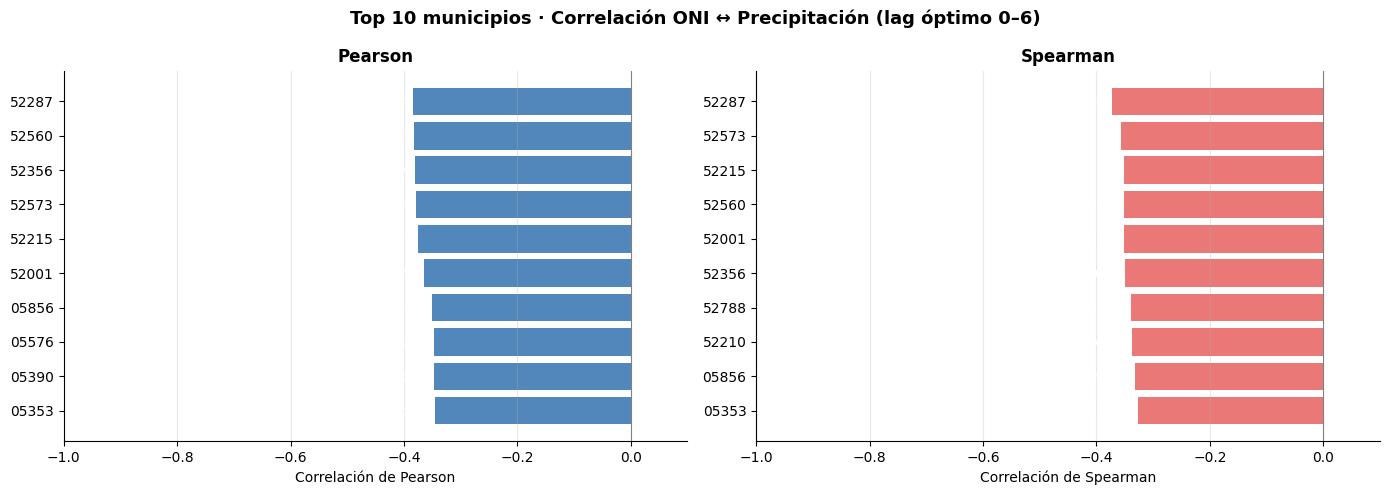

In [6]:
# ── Gráfico comparativo: top 10 Pearson vs Spearman ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Top {TOP_N} municipios · Correlación ONI ↔ Precipitación (lag óptimo 0–{MAX_LAG})",
    fontsize=13, fontweight="bold"
)

# Pearson
ax1.barh(
    top_pearson["muni_code"],
    top_pearson["pearson_corr"],
    color="#185FA5", alpha=0.75,
)
for i, row in top_pearson.iterrows():
    ax1.text(
        row["pearson_corr"] - 0.01, i,
        f"lag {int(row['pearson_lag'])}m",
        va="center", ha="right", fontsize=8, color="white"
    )
ax1.axvline(0, color="gray", linewidth=0.8)
ax1.set_xlabel("Correlación de Pearson")
ax1.set_title("Pearson", fontweight="bold")
ax1.set_xlim(-1, 0.1)
ax1.grid(axis="x", alpha=0.3)
ax1.yaxis.set_inverted(True)

# Spearman
ax2.barh(
    top_spearman["muni_code"],
    top_spearman["spearman_corr"],
    color="#E24B4A", alpha=0.75,
)
for i, row in top_spearman.iterrows():
    ax2.text(
        row["spearman_corr"] - 0.01, i,
        f"lag {int(row['spearman_lag'])}m",
        va="center", ha="right", fontsize=8, color="white"
    )
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.set_xlabel("Correlación de Spearman")
ax2.set_title("Spearman", fontweight="bold")
ax2.set_xlim(-1, 0.1)
ax2.grid(axis="x", alpha=0.3)
ax2.yaxis.set_inverted(True)

plt.tight_layout()
plt.show()

In [7]:
# ── Municipios que aparecen en ambos top 10 ───────────────────────────────
en_ambos = set(top_pearson["muni_code"]) & set(top_spearman["muni_code"])
print(f"Municipios en el top {TOP_N} de AMBOS métodos ({len(en_ambos)}):")
if en_ambos:
    df_ambos = df_corr[df_corr["muni_code"].isin(en_ambos)].copy()
    df_ambos = df_ambos.sort_values("pearson_corr").reset_index(drop=True)
    print(df_ambos.to_string(index=False))
else:
    print("Ninguno — los dos métodos identifican municipios distintos")

Municipios en el top 10 de AMBOS métodos (8):
muni_code  pearson_corr  pearson_lag  pearson_pval  spearman_corr  spearman_lag  spearman_pval
    52287       -0.3833            2           0.0        -0.3719             2            0.0
    52560       -0.3820            2           0.0        -0.3518             2            0.0
    52356       -0.3806            1           0.0        -0.3491             2            0.0
    52573       -0.3781            2           0.0        -0.3572             2            0.0
    52215       -0.3754            2           0.0        -0.3523             2            0.0
    52001       -0.3652            2           0.0        -0.3506             2            0.0
    05856       -0.3510            1           0.0        -0.3318             1            0.0
    05353       -0.3456            1           0.0        -0.3273             1            0.0
